In [4]:
import cv2
import numpy as np
from openvino.runtime import Core

# 1. Khởi tạo OpenVINO Core
ie = Core()

# 2. Đọc model YOLOv11 (Lưu ý: Thay đổi đường dẫn đúng thư mục của bạn)
model_xml = "yolo11n_openvino_model/yolo11n.xml"
model_bin = "yolo11n_openvino_model/yolo11n.bin"

print("--- Đang nạp Model vào GPU Intel Arc 140V... ---")
net = ie.read_model(model=model_xml, weights=model_bin)

# 3. Ép chạy trên GPU (Đây là lúc nhân đồ họa 16GB của bạn hoạt động)
compiled_model = ie.compile_model(model=net, device_name="GPU")
output_layer = compiled_model.output(0)

# In tên thiết bị thực tế đang chạy
device_name = ie.get_property("GPU", "FULL_DEVICE_NAME")
print(f"--- Đang chạy trên: {device_name} ---")

# 4. Đọc ảnh (Thay 'bus.jpg' bằng đường dẫn ảnh của bạn)
img = cv2.imread("bus.jpg")
if img is None:
    print("Không tìm thấy file ảnh!")
    exit()

# Tiền xử lý ảnh theo chuẩn YOLO (640x640, float32, chuẩn hóa 0-1)
blob = cv2.resize(img, (640, 640))
blob = blob.transpose(2, 0, 1)  # HWC -> CHW
blob = np.expand_dims(blob, 0).astype(np.float32) / 255.0  # Thêm batch dimension

# 5. Thực hiện suy luận (Inference)
print("--- Đang xử lý... ---")
# Đo thời gian thực thi
import time
start_time = time.time()
results = compiled_model([blob])[output_layer]
end_time = time.time()

print(f"--- Xử lý xong! ---")
print(f"Thời gian Inference trên GPU: {(end_time - start_time)*1000:.2f} ms")

# results lúc này là ma trận (1, 84, 8400) chứa các dự đoán.
# Để vẽ box, bạn cần thực hiện NMS (Non-Maximum Suppression).

--- Đang nạp Model vào GPU Intel Arc 140V... ---
--- Đang chạy trên: Intel(R) Arc(TM) 140V GPU (16GB) (iGPU) ---
--- Đang xử lý... ---
--- Xử lý xong! ---
Thời gian Inference trên GPU: 1756.66 ms


In [7]:
import os
import cv2
import math
import glob
import yaml
import shutil
import random
import xml.etree.ElementTree as ET

from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

In [8]:
# Dataset gốc
path = r"C:\Users\VanAnhLe\OneDrive - MGH\Documents\CITD\thesis\data"
DATASET_ROOT = Path(path)

# Nơi xuất dataset YOLO
YOLO_ROOT = Path("/ua_detrac_yolo")
YOLO_ROOT.mkdir(parents=True, exist_ok=True)

print("DATASET_ROOT exists:", DATASET_ROOT.exists())

DATASET_ROOT exists: True


4) Tìm XML và sequence ảnh

In [10]:
def find_candidate_files(root: Path):
    xml_files = list(root.rglob("*.xml"))
    img_files = list(root.rglob("*.jpg")) + list(root.rglob("*.png"))

    print(f"XML files: {len(xml_files)}")
    print(f"Image files: {len(img_files)}")

    print("\nSample XML:")
    for p in xml_files[:5]:
        print(" -", p)

    print("\nSample images:")
    for p in img_files[:5]:
        print(" -", p)

    return xml_files, img_files

xml_files, img_files = find_candidate_files(DATASET_ROOT)

XML files: 100
Image files: 140147

Sample XML:
 - C:\Users\VanAnhLe\OneDrive - MGH\Documents\CITD\thesis\data\DETRAC-Test-Annotations-XML\DETRAC-Test-Annotations-XML\MVI_39031.xml
 - C:\Users\VanAnhLe\OneDrive - MGH\Documents\CITD\thesis\data\DETRAC-Test-Annotations-XML\DETRAC-Test-Annotations-XML\MVI_39051.xml
 - C:\Users\VanAnhLe\OneDrive - MGH\Documents\CITD\thesis\data\DETRAC-Test-Annotations-XML\DETRAC-Test-Annotations-XML\MVI_39211.xml
 - C:\Users\VanAnhLe\OneDrive - MGH\Documents\CITD\thesis\data\DETRAC-Test-Annotations-XML\DETRAC-Test-Annotations-XML\MVI_39271.xml
 - C:\Users\VanAnhLe\OneDrive - MGH\Documents\CITD\thesis\data\DETRAC-Test-Annotations-XML\DETRAC-Test-Annotations-XML\MVI_39311.xml

Sample images:
 - C:\Users\VanAnhLe\OneDrive - MGH\Documents\CITD\thesis\data\DETRAC-Images\DETRAC-Images\MVI_20011\img00001.jpg
 - C:\Users\VanAnhLe\OneDrive - MGH\Documents\CITD\thesis\data\DETRAC-Images\DETRAC-Images\MVI_20011\img00002.jpg
 - C:\Users\VanAnhLe\OneDrive - MGH\Documen

In [11]:
def collect_sequence_dirs(root: Path):
    seq_dirs = {}
    for d in root.rglob("*"):
        if d.is_dir():
            imgs = list(d.glob("*.jpg")) + list(d.glob("*.png"))
            if len(imgs) > 10:
                seq_dirs[d.name] = d
    return seq_dirs

seq_dirs = collect_sequence_dirs(DATASET_ROOT)
print("Sequence dirs found:", len(seq_dirs))
for k in list(seq_dirs.keys())[:10]:
    print(k, "->", seq_dirs[k])

Sequence dirs found: 100
MVI_20011 -> C:\Users\VanAnhLe\OneDrive - MGH\Documents\CITD\thesis\data\DETRAC-Images\DETRAC-Images\MVI_20011
MVI_20012 -> C:\Users\VanAnhLe\OneDrive - MGH\Documents\CITD\thesis\data\DETRAC-Images\DETRAC-Images\MVI_20012
MVI_20032 -> C:\Users\VanAnhLe\OneDrive - MGH\Documents\CITD\thesis\data\DETRAC-Images\DETRAC-Images\MVI_20032
MVI_20033 -> C:\Users\VanAnhLe\OneDrive - MGH\Documents\CITD\thesis\data\DETRAC-Images\DETRAC-Images\MVI_20033
MVI_20034 -> C:\Users\VanAnhLe\OneDrive - MGH\Documents\CITD\thesis\data\DETRAC-Images\DETRAC-Images\MVI_20034
MVI_20035 -> C:\Users\VanAnhLe\OneDrive - MGH\Documents\CITD\thesis\data\DETRAC-Images\DETRAC-Images\MVI_20035
MVI_20051 -> C:\Users\VanAnhLe\OneDrive - MGH\Documents\CITD\thesis\data\DETRAC-Images\DETRAC-Images\MVI_20051
MVI_20052 -> C:\Users\VanAnhLe\OneDrive - MGH\Documents\CITD\thesis\data\DETRAC-Images\DETRAC-Images\MVI_20052
MVI_20061 -> C:\Users\VanAnhLe\OneDrive - MGH\Documents\CITD\thesis\data\DETRAC-Images\

5) Map class từ UA-DETRAC sang 4 class

UA-DETRAC thường có vehicle_type trong XML. Ta chuẩn hóa về 4 nhãn này. Dataset detection của Ultralytics chỉ cần class id + bbox YOLO normalized trong file .txt, và khai báo tên class trong data.yaml.

In [12]:
CLASS_NAMES = ["car", "van", "bus", "others"]
CLASS2ID = {name: i for i, name in enumerate(CLASS_NAMES)}

def normalize_vehicle_type(vtype: str):
    if vtype is None:
        return "others"

    v = vtype.strip().lower()

    # tùy bản annotation, có thể gặp một số tên khác nhau
    if v in ["car", "sedan", "hatchback", "suv", "mini-van"]:
        return "car"
    elif v in ["van"]:
        return "van"
    elif v in ["bus", "coach"]:
        return "bus"
    else:
        return "others"

6) Parse XML UA-DETRAC thành annotation theo frame

In [13]:
def parse_detrac_xml(xml_path):
    """
    return:
    {
        frame_id: [
            {
                "id": int,
                "left": float,
                "top": float,
                "width": float,
                "height": float,
                "vehicle_type": str
            },
            ...
        ]
    }
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    frame_dict = defaultdict(list)

    for frame in root.findall(".//frame"):
        frame_num = frame.attrib.get("num")
        if frame_num is None:
            continue
        frame_num = int(frame_num)

        for target in frame.findall(".//target"):
            target_id = target.attrib.get("id", "-1")

            box = target.find(".//box")
            attr = target.find(".//attribute")

            if box is None:
                continue

            left = float(box.attrib.get("left", 0))
            top = float(box.attrib.get("top", 0))
            width = float(box.attrib.get("width", 0))
            height = float(box.attrib.get("height", 0))

            if width <= 0 or height <= 0:
                continue

            vehicle_type = "others"
            if attr is not None:
                vehicle_type = normalize_vehicle_type(attr.attrib.get("vehicle_type", "others"))

            frame_dict[frame_num].append({
                "id": int(target_id) if str(target_id).isdigit() else -1,
                "left": left,
                "top": top,
                "width": width,
                "height": height,
                "vehicle_type": vehicle_type
            })

    return frame_dict

7) Ghép XML với sequence ảnh

In [14]:
def find_best_seq_for_xml(xml_path: Path, seq_dirs: dict):
    stem = xml_path.stem.lower()

    # match trực tiếp
    for seq_name, seq_dir in seq_dirs.items():
        if seq_name.lower() == stem:
            return seq_dir

    # match chứa nhau
    for seq_name, seq_dir in seq_dirs.items():
        if stem in seq_name.lower() or seq_name.lower() in stem:
            return seq_dir

    return None

matched_pairs = []
for xml_path in xml_files:
    seq_dir = find_best_seq_for_xml(xml_path, seq_dirs)
    if seq_dir is not None:
        matched_pairs.append((xml_path, seq_dir))

print("Matched pairs:", len(matched_pairs))
for xml_path, seq_dir in matched_pairs[:10]:
    print(xml_path.name, "<->", seq_dir.name)

Matched pairs: 100
MVI_39031.xml <-> MVI_39031
MVI_39051.xml <-> MVI_39051
MVI_39211.xml <-> MVI_39211
MVI_39271.xml <-> MVI_39271
MVI_39311.xml <-> MVI_39311
MVI_39361.xml <-> MVI_39361
MVI_39371.xml <-> MVI_39371
MVI_39401.xml <-> MVI_39401
MVI_39501.xml <-> MVI_39501
MVI_39511.xml <-> MVI_39511


8) Chia train/val theo sequence

Chia theo sequence sẽ tránh leakage giữa các frame gần nhau của cùng video.

In [ ]:
random.seed(42)
random.shuffle(matched_pairs)

val_ratio = 0.2
n_val = max(1, int(len(matched_pairs) * val_ratio))

val_pairs = matched_pairs[:n_val]
train_pairs = matched_pairs[n_val:]

print("Train sequences:", len(train_pairs))
print("Val sequences:", len(val_pairs))

Train sequences: 80
Val sequences: 20


In [ ]:
# 9) Tạo thư mục YOLO
IMAGES_DIR = YOLO_ROOT / "images"
LABELS_DIR = YOLO_ROOT / "labels"

for split in ["train", "val"]:
    (IMAGES_DIR / split).mkdir(parents=True, exist_ok=True)
    (LABELS_DIR / split).mkdir(parents=True, exist_ok=True)

# 10) Convert bbox sang YOLO format
def convert_box_to_yolo(left, top, width, height, img_w, img_h):
    x_center = (left + width / 2) / img_w
    y_center = (top + height / 2) / img_h
    w = width / img_w
    h = height / img_h
    return x_center, y_center, w, h

# 11) Convert UA-DETRAC XML -> YOLO detection format 4 class
def convert_pairs_to_yolo(pairs, split_name):
    image_count = 0
    box_count = 0
    class_counter = defaultdict(int)

    for xml_path, seq_dir in tqdm(pairs, desc=f"Convert {split_name}"):
        frame_ann = parse_detrac_xml(xml_path)

        img_paths = sorted(list(seq_dir.glob("*.jpg")) + list(seq_dir.glob("*.png")))
        if not img_paths:
            continue

        for img_path in img_paths:
            stem = img_path.stem
            digits = "".join([c for c in stem if c.isdigit()])
            if not digits:
                continue
            frame_num = int(digits)

            img = cv2.imread(str(img_path))
            if img is None:
                continue

            h, w = img.shape[:2]
            anns = frame_ann.get(frame_num, [])

            out_img_name = f"{seq_dir.name}_{img_path.name}"
            out_img_path = IMAGES_DIR / split_name / out_img_name
            shutil.copy2(img_path, out_img_path)
            image_count += 1

            out_label_path = LABELS_DIR / split_name / f"{Path(out_img_name).stem}.txt"

            with open(out_label_path, "w") as f:
                for ann in anns:
                    left = ann["left"]
                    top = ann["top"]
                    bw = ann["width"]
                    bh = ann["height"]
                    cls_name = ann["vehicle_type"]
                    cls_id = CLASS2ID[cls_name]

                    # clamp
                    left = max(0, min(left, w - 1))
                    top = max(0, min(top, h - 1))
                    bw = max(1, min(bw, w - left))
                    bh = max(1, min(bh, h - top))

                    x, y, ww, hh = convert_box_to_yolo(left, top, bw, bh, w, h)

                    if not (0 < ww <= 1 and 0 < hh <= 1 and 0 <= x <= 1 and 0 <= y <= 1):
                        continue

                    f.write(f"{cls_id} {x:.6f} {y:.6f} {ww:.6f} {hh:.6f}\n")
                    box_count += 1
                    class_counter[cls_name] += 1

    print(f"\n[{split_name}] images = {image_count}, boxes = {box_count}")
    print(f"[{split_name}] class distribution:")
    for cname in CLASS_NAMES:
        print(f"  {cname:>6}: {class_counter[cname]}")

convert_pairs_to_yolo(train_pairs, "train")
convert_pairs_to_yolo(val_pairs, "val")

Convert train: 100%|██████████| 80/80 [06:39<00:00,  5.00s/it]



[train] images = 113620, boxes = 1015120
[train] class distribution:
     car: 904627
   truck: 0
     bus: 95024
  others: 15469


Convert val: 100%|██████████| 20/20 [01:34<00:00,  4.71s/it]


[val] images = 26511, boxes = 258935
[val] class distribution:
     car: 243351
   truck: 0
     bus: 10412
  others: 5172


12) Tạo data.yaml cho 4 class

File YAML mô tả đường dẫn train/val và tên class là định dạng chuẩn cho custom detection dataset trong Ultralytics.

In [ ]:
data_yaml = {
    "path": str(YOLO_ROOT),
    "train": "images/train",
    "val": "images/val",
    "names": {
        0: "car",
        1: "van",
        2: "bus",
        3: "others"
    }
}

yaml_path = YOLO_ROOT / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)

print(yaml_path.read_text())

path: /content/ua_detrac_yolo
train: images/train
val: images/val
names:
  0: car
  1: truck
  2: bus
  3: others



13) Kiểm tra sample labels

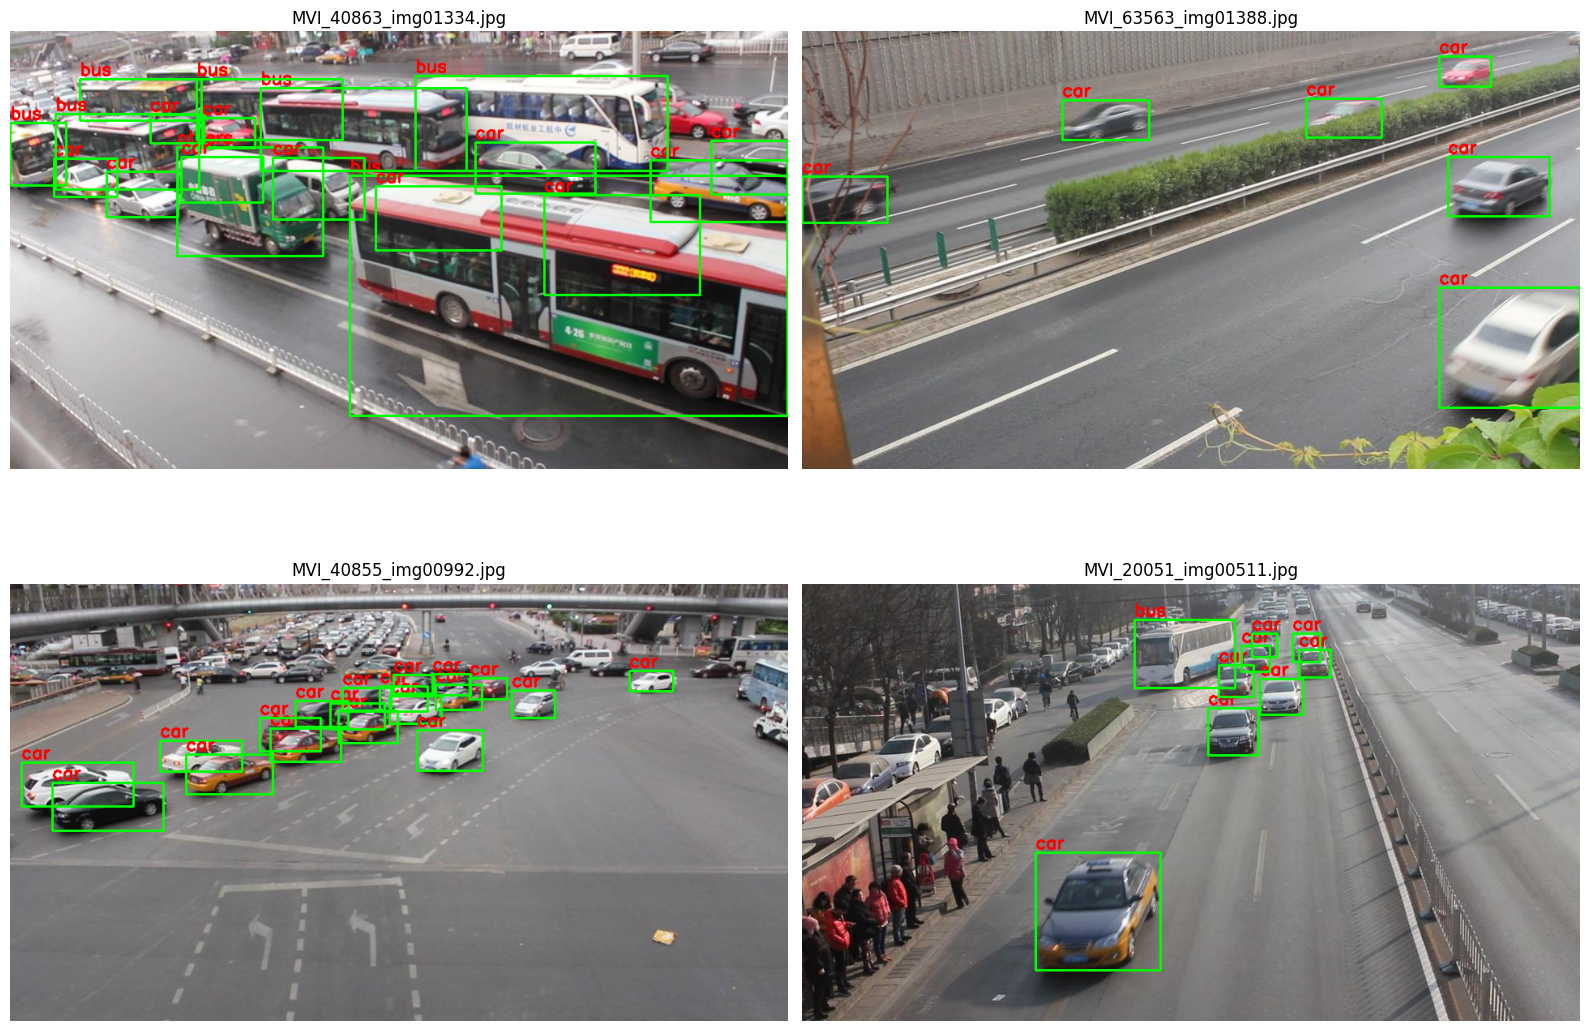

In [ ]:
import matplotlib.pyplot as plt

ID2CLASS = {v: k for k, v in CLASS2ID.items()}

def show_random_samples(images_dir, labels_dir, n=4):
    img_paths = list(Path(images_dir).glob("*.*"))
    if len(img_paths) == 0:
        print("No images found.")
        return

    samples = random.sample(img_paths, min(n, len(img_paths)))

    plt.figure(figsize=(16, 12))
    for i, img_path in enumerate(samples, 1):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        label_path = Path(labels_dir) / f"{img_path.stem}.txt"
        if label_path.exists():
            lines = label_path.read_text().strip().splitlines()
            for line in lines:
                parts = line.split()
                if len(parts) != 5:
                    continue

                cls_id = int(float(parts[0]))
                xc, yc, bw, bh = map(float, parts[1:])

                x1 = int((xc - bw/2) * w)
                y1 = int((yc - bh/2) * h)
                x2 = int((xc + bw/2) * w)
                y2 = int((yc + bh/2) * h)

                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(
                    img,
                    ID2CLASS.get(cls_id, str(cls_id)),
                    (x1, max(20, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (255, 0, 0),
                    2
                )

        plt.subplot(math.ceil(n/2), 2, i)
        plt.imshow(img)
        plt.title(img_path.name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_samples(IMAGES_DIR / "train", LABELS_DIR / "train", n=4)

14) Train YOLO11n với 4 class

Ultralytics hỗ trợ train bằng Python API YOLO(...).train(...), và YOLO11 là dòng model hỗ trợ detection và tracking workflow.

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
train_results = model.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=4,
    pretrained=True,
    cache=True,
    patience=15,
    project="/content/runs",
    name="yolo11n_ua_detrac_4cls"
)

# 15) Validate model
metrics = model.val(
    data=str(yaml_path),
    split="val",
    imgsz=640,
    device=0
)

print(metrics)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ua_detrac_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, in

16) Test predict trên ảnh

In [ ]:
val_images = list((IMAGES_DIR / "val").glob("*.*"))
test_img = str(random.choice(val_images))

preds = model.predict(
    source=test_img,
    conf=0.25,
    imgsz=640,
    save=True,
    project="/content/runs",
    name="predict_4cls"
)

17) Tạo video từ 1 sequence ảnh để tracking

Ultralytics tracking hoạt động trên video/stream; ByteTrack được cấu hình qua file tracker YAML trong chế độ track.

In [ ]:
def make_video_from_sequence(seq_dir, output_video, fps=25):
    img_paths = sorted(list(Path(seq_dir).glob("*.jpg")) + list(Path(seq_dir).glob("*.png")))
    assert len(img_paths) > 0, f"No images in {seq_dir}"

    first = cv2.imread(str(img_paths[0]))
    h, w = first.shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_video), fourcc, fps, (w, h))

    for p in tqdm(img_paths, desc=f"Create video {Path(seq_dir).name}"):
        img = cv2.imread(str(p))
        writer.write(img)

    writer.release()

demo_xml, demo_seq_dir = val_pairs[0]
demo_video = Path("/content/demo_seq.mp4")

make_video_from_sequence(demo_seq_dir, demo_video, fps=25)
print("Saved:", demo_video)

18) ByteTrack track đa phương tiện cùng lúc:

detector xuất ra bbox + class cho từng object

ByteTrack gán track_id cho từng object qua các frame

kết quả mỗi track vẫn giữ class tương ứng

In [ ]:
best_model_path = "/content/runs/yolo11n_ua_detrac_4cls/weights/best.pt"
track_model = YOLO(best_model_path)

track_results = track_model.track(
    source=str(demo_video),
    tracker="bytetrack.yaml",
    conf=0.25,
    iou=0.5,
    imgsz=640,
    persist=True,
    save=True,
    show=False,
    project="/content/runs",
    name="track_4cls_bytetrack"
)

19) ByteTrack custom để ổn định hơn trong traffic (tuning)

In [ ]:
bytetrack_custom = """
tracker_type: bytetrack
track_high_thresh: 0.45
track_low_thresh: 0.10
new_track_thresh: 0.50
track_buffer: 40
match_thresh: 0.80
fuse_score: True
"""

custom_tracker_path = "/content/bytetrack_traffic.yaml"
with open(custom_tracker_path, "w") as f:
    f.write(bytetrack_custom)

print(open(custom_tracker_path).read())

track_results = track_model.track(
    source=str(demo_video),
    tracker=custom_tracker_path,
    conf=0.20,
    iou=0.5,
    imgsz=640,
    persist=True,
    save=True,
    show=False,
    project="/content/runs",
    name="track_4cls_bytetrack_custom"
)

20) Hiển thị video kết quả trong Colab

In [ ]:
from IPython.display import Video, display
from pathlib import Path

candidates = list(Path("/content/runs").rglob("*.mp4")) + list(Path("/content/runs").rglob("*.avi"))
for c in candidates[-10:]:
    print(c)

# sửa path đúng theo file output thực tế in ra ở cell trên
result_video = candidates[-1]
display(Video(str(result_video), embed=True))